<a href="https://colab.research.google.com/github/anujjakhotiya/AI-DL_2026/blob/main/Lab_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch [100/500], Loss: 0.7003
Epoch [200/500], Loss: 0.3372
Epoch [300/500], Loss: 0.1492
Epoch [400/500], Loss: 0.0830
Epoch [500/500], Loss: 0.0581

Accuracy: 0.9666666666666667

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


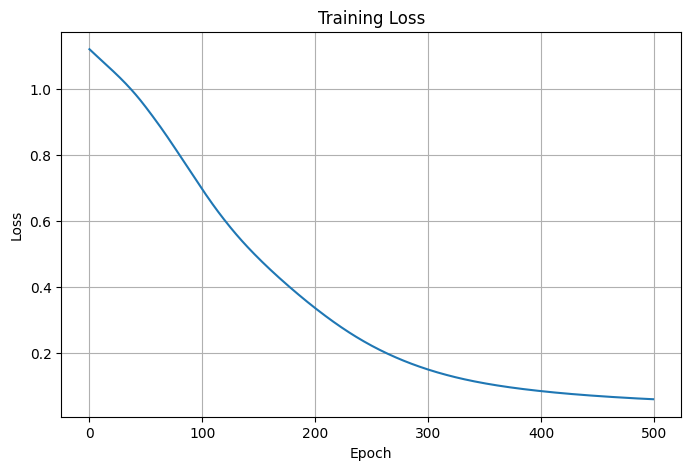

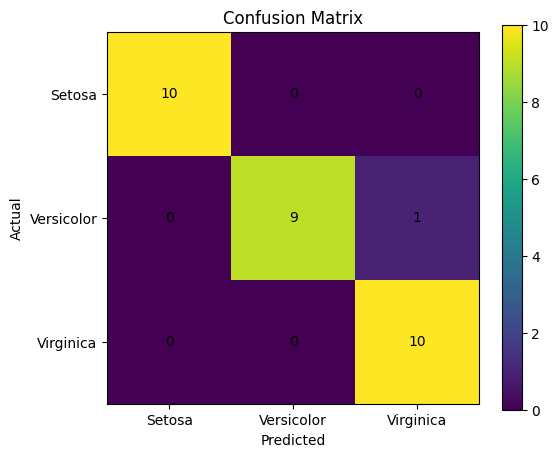

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("Iris.csv")

# Remove ID column
df = df.drop("Id", axis=1)

# Convert target to numbers
df["Species"] = df["Species"].map({
    "Iris-setosa": 0,
    "Iris-versicolor": 1,
    "Iris-virginica": 2
})

# Features and target
X = df.drop("Species", axis=1).values
y = df["Species"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)


# ANN Model
class ANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(4, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 3)
        )

    def forward(self, x):
        return self.model(x)


model = ANN()

# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training
epochs = 500
losses = []

for epoch in range(epochs):

    output = model(X_train)
    loss = criterion(output, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}")


# Prediction
with torch.no_grad():
    output = model(X_test)
    predictions = torch.argmax(output, dim=1)


# Evaluation
y_test_np = y_test.numpy()
predictions_np = predictions.numpy()

accuracy = accuracy_score(y_test_np, predictions_np)

print("\nAccuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(
    y_test_np,
    predictions_np,
    target_names=[
        "Iris-setosa",
        "Iris-versicolor",
        "Iris-virginica"
    ]
))

print("Confusion Matrix:")
print(confusion_matrix(y_test_np, predictions_np))


# Loss Plot
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()
plt.show()


# Confusion Matrix Plot
cm = confusion_matrix(y_test_np, predictions_np)

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks(
    [0, 1, 2],
    ["Setosa", "Versicolor", "Virginica"]
)

plt.yticks(
    [0, 1, 2],
    ["Setosa", "Versicolor", "Virginica"]
)

plt.show()